In [2]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from tqdm import tqdm

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.LeafletFAminibatch as LeafletFAminibatch
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

# Simulation source code
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
importlib.reload(sim)


Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [3]:
# Define base output directory
import json 
base_output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19"

# Get parameter set ID from command line
# param_id = int(sys.argv[1])
param_id = 0 

# Load parameters
param_file = os.path.join(base_output_dir, "parameter_combinations.json")
with open(param_file, "r") as f:
    param_list = json.load(f)
params = param_list[param_id] 

# Define output directory
output_dir = os.path.join(base_output_dir, f"run_{param_id}")
os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19/run_0


In [4]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

In [5]:
# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

### Simulate data!

In [6]:
# Filter adata to only include junctions that have non_zero_count_cells >= 10
adata = adata[:, adata.var["non_zero_count_cells"] > 2]

# choose which column should be used for maintaining cell labels when simulating data...
sim_label_column = params["sim_label_column"] #"cell_type_grouped" # or set to None then cells will be randomly assigned to groups
proportion_negative = params["proportion_negative"]

if params["sim_label_column"] is None:
    K = 2
else:
    K = len(adata.obs[sim_label_column].unique())

# Set up some useful params 
params["input_conc"] = None if params["input_conc"] is None else torch.tensor(np.inf)
input_conc = params["input_conc"]
junc_specific_prior = params["junc_specific_prior"] # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
waypoints_use = params["waypoints_use"] # don't have waypoints in simulated data

In [7]:
sim_label_column = "cell_type_grouped"
K = len(adata.obs[sim_label_column].unique())
proportion_negative = 0.5
print(K)

9


In [8]:
# Preprocess the data
adata_filtered = sim.preprocess_adata(adata, sim_label_column, "cell_by_cluster_matrix")
# Simulate data
_, _, adata_input, cell_type_psi_df = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, sim_label_column)

# Write cell_type_psi_df to a CSV file 
cell_type_psi_df_path = os.path.join(output_dir, 'cell_type_psi_df.csv')
cell_type_psi_df.to_csv(cell_type_psi_df_path, index=False)

Filtering ATSEs to remove those very unevenly distributed across cell types!


100%|██████████| 9/9 [00:28<00:00,  3.18s/it]
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:281: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_junc_counts =  adata_input.var.groupby(["event_id"]).agg({"junction_id": "count"}).reset_index()
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:307: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, juncs_c in tqdm( adata_input.var.groupby("event_id")):


Cluster_Counts nnz: 14507235
Junction_Counts nnz: 8005369
The number of unique junctions included in the simulation data is: 10170
The number of unique clusters included in the simulation data is: 3390


100%|██████████| 3390/3390 [00:03<00:00, 1117.31it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 14004504
Junction_Counts nnz: 7578659
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 9
The number of cells is: 19942
The number of junctions is: 9798
Number of negative labels (0): 1633
Number of positive labels (1): 1633


...

Processing ATSEs: 100%|██████████| 3266/3266 [00:58<00:00, 55.61it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Done normalizing junction counts by cluster!
Done simulating junction counts!
True label counts:
 true_label
positive    4899
negative    4899
Name: count, dtype: int64
Sample label counts:
 sample_label
positive    4899
negative    4899
Name: count, dtype: int64


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'junc_ratio' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Cluster_Counts nnz: 13833339
Junction_Counts nnz: 11996182
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [9]:
# Check column names that are not strings
problematic_columns = [col for col in adata_input.var.columns if not isinstance(col, str)]
print("Problematic columns:", problematic_columns)

# Convert problematic column names to strings
adata_input.var.columns = adata_input.var.columns.map(str)

if adata_input.var.columns.duplicated().any():
    print("Duplicate column names found. Resolving by renaming.")
    adata_input.var.columns = pd.io.parsers.ParserBase({'names': adata_input.var.columns})._maybe_dedup_names(adata_input.var.columns)

import scipy 
from scipy.sparse import csr_matrix

# Check if any layers are in COO format
for layer_name, layer_data in adata_input.layers.items():
    if isinstance(layer_data, scipy.sparse.coo_matrix):
        print(f"Converting {layer_name} from COO to CSR format.")
        adata_input.layers[layer_name] = layer_data.tocsr()

# Convert adata.X if it is in COO format
if isinstance(adata_input.X, scipy.sparse.coo_matrix):
    print("Converting adata.X from COO to CSR format.")
    adata_input.X = adata_input.X.tocsr()

# Convert varm, obsm, and obsp if they contain COO matrices
for attr in ['varm', 'obsm', 'obsp']:
    for key in getattr(adata_input, attr).keys():
        if isinstance(getattr(adata_input, attr)[key], scipy.sparse.coo_matrix):
            print(f"Converting {attr}['{key}'] from COO to CSR format.")
            getattr(adata_input, attr)[key] = getattr(adata_input, attr)[key].tocsr()

# save adata_input to h5ad file
output_anndata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED"
# get todays date
today = datetime.datetime.now()
today = today.strftime("%Y-%m-%d")
#adata_input.write_h5ad(f"{output_anndata}/simulated_data_{today}.h5ad")
#print(f"Simulated anndata saved to {output_anndata}/simulated_data_{today}.h5ad")


Problematic columns: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Converting cell_by_junction_matrix from COO to CSR format.
Converting cell_by_cluster_matrix from COO to CSR format.


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


### Initialize and train the model using the simulated counts!

In [10]:
num_inits = params["num_inits"]
num_samples = params["num_samples"]
lr = params["lr"]
ELBO_num_particles = params["ELBO_num_particles"]

In [11]:
adata_input

AnnData object with n_obs × n_vars = 19942 × 9798
    obs: 'cell_id', 'age', 'batch', 'cell_ontology_class', 'method', 'mouse.id', 'sex', 'tissue', 'old_cell_id_index', 'cell_clean', 'cell_id_index', 'subtissue_clean', 'cell_type_grouped', 'cell_type'
    var: 'junction_id', 'event_id', 'splice_motif', 'label_5_prime', 'label_3_prime', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index', 'chr', 'start', 'end', 'index', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'sample_label', 'difference', 'true_label'
    uns: 'age_colors', 'neighbors', 'pca_explained_variance_ratio', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'phi_init_100_waypoints', 'phi_init_30_waypoints'
    varm: 'psi_init_100_waypoints', 'psi_init_30_waypoints'
    layers: 'cell_by_junction_matrix', 'cel

In [12]:
# Let's initialize the LeafletFA class 
importlib.reload(LeafletFAminibatch)

Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'BetaDirichletFactor.LeafletFAminibatch' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/LeafletFAminibatch.py'>

In [13]:
input_conc = np.inf

In [14]:
leaflet_model = LeafletFAminibatch.LeafletFA(adata=adata_input, 
                                                 K=10,  # Increase K to capture more factors (you can prune later)
                                    junc_specific_prior = False, 
                                    waypoints_use=waypoints_use, 
                           input_conc_prior = input_conc, 
                           num_epochs=100, 
                           batch_size = 10000,
                           print_epochs=5, 
                           patience=15, 
                           min_delta=2, 
                           ELBO_num_particles=5,  # More particles for better ELBO estimates
                           lr=0.5,
                           gamma=0.02, #slower decay 
                           num_samples=50)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

Batch size for training: 10000 cells
Taking in the AnnData object with 19942 cells and 9798 junctions.
Processing AnnData on cuda


In [15]:
!export CUDA_LAUNCH_BLOCKING=1

Random seeds: [9718]
Training LeafletFA with 1 initializations.
Input concentration prior: inf
Junction-specific prior: False
Initial K to learn: 10
Random initialization of variational parameters!
-------------------------------------------------
Initialization #1 with seed 9718
-------------------------------------------------
Training in progress for 100 epochs!
Number of cells: 19942, using batch size: 10000


  1%|          | 1/100 [00:10<17:27, 10.58s/it]

Epoch 0: Loss = 15318224995.69764, LR = 0.46237101811809306, Log Likelihood = -15316049920.0


  6%|▌         | 6/100 [00:12<01:38,  1.05s/it]

Epoch 5: Loss = 12542647697.092428, LR = 0.3126753205970494, Log Likelihood = -12536803328.0


...

 96%|█████████▌| 96/100 [00:55<00:01,  2.13it/s]

Epoch 95: Loss = 939080653.3024002, LR = 0.0002734938695990969, Log Likelihood = -939975104.0


100%|██████████| 100/100 [00:57<00:00,  1.74it/s]

Training completed after 100 epochs.
No output directory specified, skipping loss plot save.


------------------------------------------------
------------------------------------------------


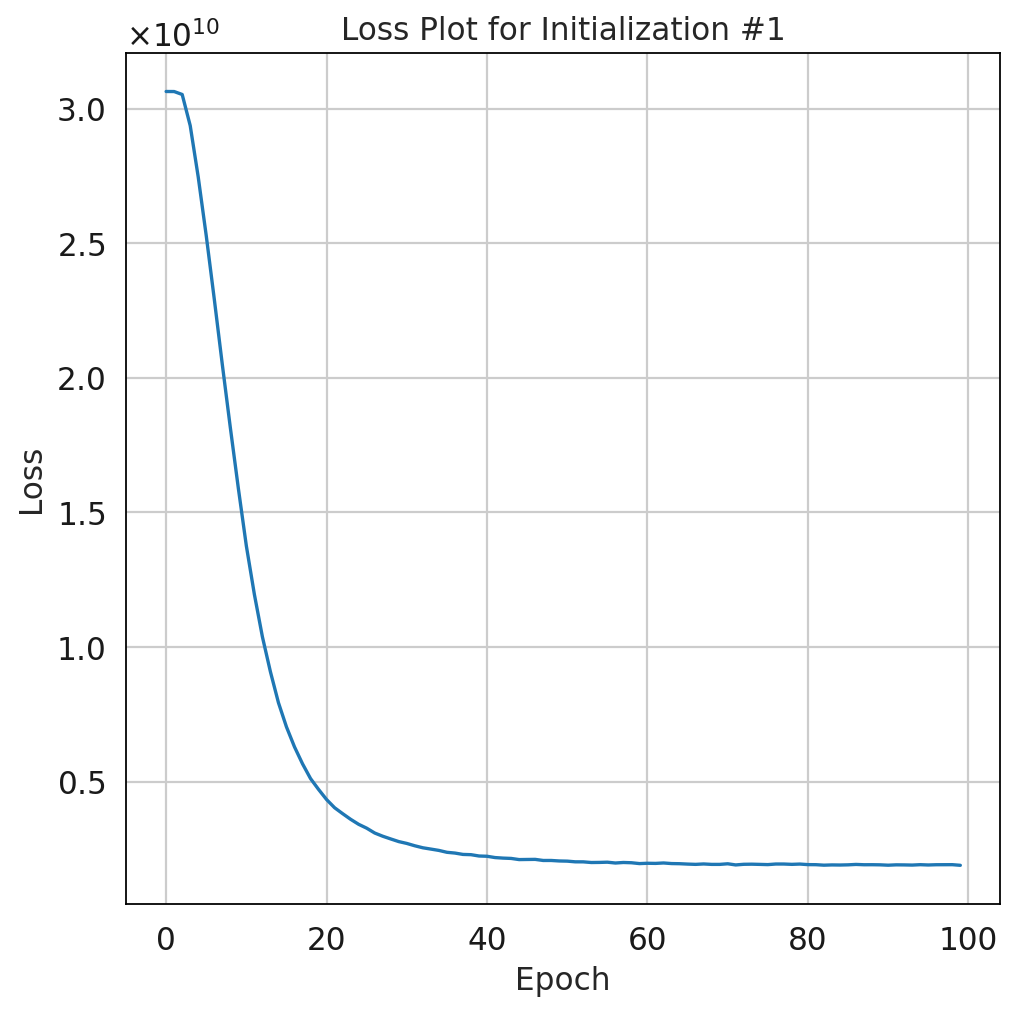

In [16]:
# Train the model 
leaflet_model.train(num_initializations=1)

In [17]:
# import Predictive pyro
import pyro
from pyro.infer import Predictive

In [18]:
def collect_all_cell_assignments_fixed(model, guide, y, total_counts, K, junc_specific_prior,
                                     input_conc_prior, device, num_samples=100):
    """
    Collect assignments for all cells using Pyro's Predictive correctly.
    """
    import pyro
    from pyro.infer import Predictive
    
    N = y.size(0)  # Total number of cells
    print(f"Collecting assignments for all {N} cells using Predictive")
    
    # Create a Predictive object for the posterior
    posterior_predictive = Predictive(
        model=model,
        guide=guide,
        num_samples=num_samples,
        return_sites=["assign", "pi", "psi", "a", "b", "a_shape", "a_rate", "b_shape", "b_rate",
                      "dir_conc", "alpha_pi", "bb_conc"],
        parallel=False
    )
    
    # Get all indices
    all_indices = torch.arange(N, device=device)
    
    # Generate predictions for all cells at once
    predictions = posterior_predictive(
        y=y,
        total_counts=total_counts,
        K=K,
        junc_specific_prior=junc_specific_prior,
        input_conc_prior=input_conc_prior,
        idx=all_indices,  # Pass all indices explicitly
        predict=False  # Don't use prediction mode since we're using proper indexing
    )
    
    # Move to CPU to save memory
    for site, samples in predictions.items():
        predictions[site] = samples.detach().cpu()
    
    print(f"Successfully collected samples for all cells.")
    print(f"Assign shape: {predictions['assign'].shape}")  # Should be [100, 19942, K]
    
    return predictions

In [19]:
guide = leaflet_model.guide
all_samples = collect_all_cell_assignments_fixed(
    model=leaflet_model.model,
    guide=guide,  # Your trained guide
    y=leaflet_model.y,
    total_counts=leaflet_model.total_counts,
    K=leaflet_model.K,
    junc_specific_prior=leaflet_model.junc_specific_prior,
    input_conc_prior=leaflet_model.input_conc_prior,
    device=leaflet_model.device,
    num_samples=100
)

# Verify the shape of the assignments
print(f"Assign shape: {all_samples['assign'].shape}")

Successfully collected samples for all cells.
Assign shape: torch.Size([100, 19942, 10])
Assign shape: torch.Size([100, 19942, 10])


In [20]:
all_samples['assign'].shape
# Calculate mean across samples (dimension 0)
phi_mean = all_samples['assign'].mean(dim=0)

In [21]:
# Verify the shape
print(f"PHI mean shape: {phi_mean.shape}")  # Should be [19942, 9]

# Convert to numpy array if it's a torch tensor
if isinstance(phi_mean, torch.Tensor):
    phi_mean = phi_mean.detach().cpu().numpy()

PHI mean shape: torch.Size([19942, 10])


... storing 'event_id' as categorical
... storing 'chr' as categorical
... storing 'start' as categorical
... storing 'end' as categorical
... storing 'sample_label' as categorical
... storing 'true_label' as categorical


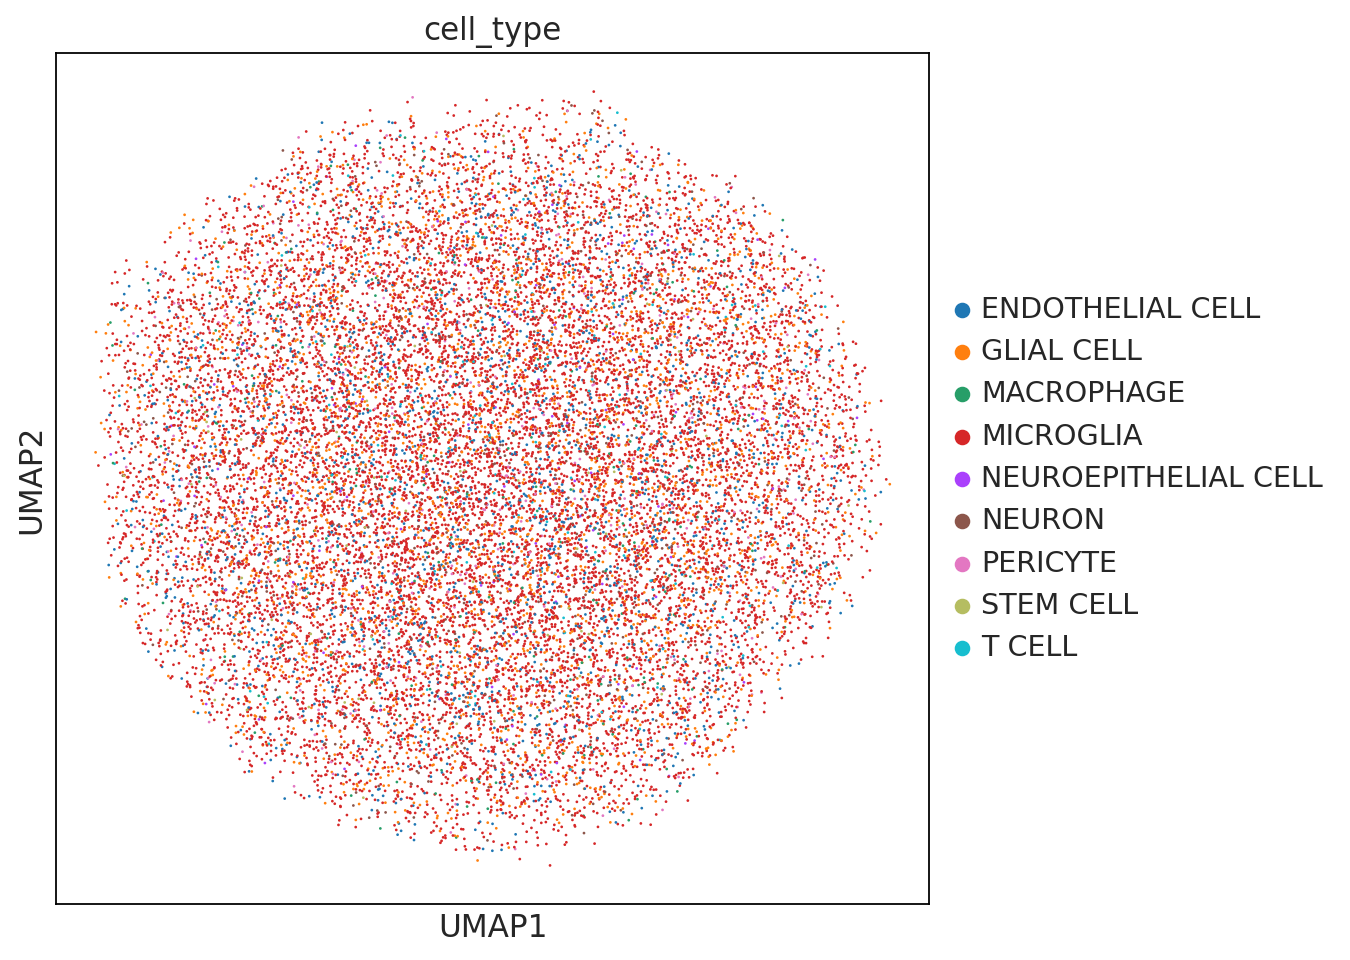

In [22]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"

adata_input.obsm[LEAFLETFA_LATENT_KEY] = phi_mean # assign_post is the posterior assignment cell-factor activity matrix 

sc.pp.neighbors(adata_input, use_rep=LEAFLETFA_LATENT_KEY, n_neighbors=10)
sc.tl.umap(adata_input)
sc.pl.umap(adata_input, color=["cell_type"])

In [23]:
cell_tye_silhouette = ds.calculate_silhouette_score(phi_mean, adata_input.obs.cell_type.values)
print(f"Silhouette score for cell types: {cell_tye_silhouette}")

Silhouette score for cell types: -0.024361899122595787


In [24]:
# Print out the distribution of various learned parameters
if 'pi' in all_samples:
    pi_mean = all_samples['pi'].mean(dim=0).detach().cpu().numpy()
    
    print("Pi distribution (factor prevalence):")
    for i, p in enumerate(pi_mean):
        print(f"Factor {i}: {p:.6f}")
    
    # Check if any factors are dominating
    print(f"Max factor weight: {pi_mean.max():.6f}, Min factor weight: {pi_mean.min():.6f}")

# Check concentration parameter
if 'dir_conc' in all_samples:
    conc_mean = all_samples['dir_conc'].mean().item()
    print(f"Dirichlet concentration: {conc_mean:.6f}")
    
    # Low concentration (<1) indicates more sparse assignments
    # High concentration (>10) indicates more uniform assignments
    if conc_mean > 10:
        print("WARNING: High concentration parameter may cause uniform factor assignments!")

Pi distribution (factor prevalence):


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
# Check variance in assignments
phi_mean = all_samples['assign'].mean(dim=0).detach().cpu().numpy()
phi_var = np.var(phi_mean, axis=0)
print(f"Variance across factors: {phi_var}")
print(f"Min variance: {phi_var.min():.6f}, Max variance: {phi_var.max():.6f}")

# Check if assignments are too uniform (each cell using all factors similarly)
phi_entropy = -np.sum(phi_mean * np.log(phi_mean + 1e-10), axis=1)
print(f"Average assignment entropy: {phi_entropy.mean():.6f}")
print(f"Min entropy: {phi_entropy.min():.6f}, Max entropy: {phi_entropy.max():.6f}")

# If entropy is high across all cells, factors aren't specialized

Variance across factors: [0.00018882 0.0001932  0.00018376 0.0001523  0.00020746 0.00015886
 0.00020764 0.00021401 0.00013341 0.0002134 ]
Min variance: 0.000133, Max variance: 0.000214
Average assignment entropy: 2.245612
Min entropy: 2.148334, Max entropy: 2.291758


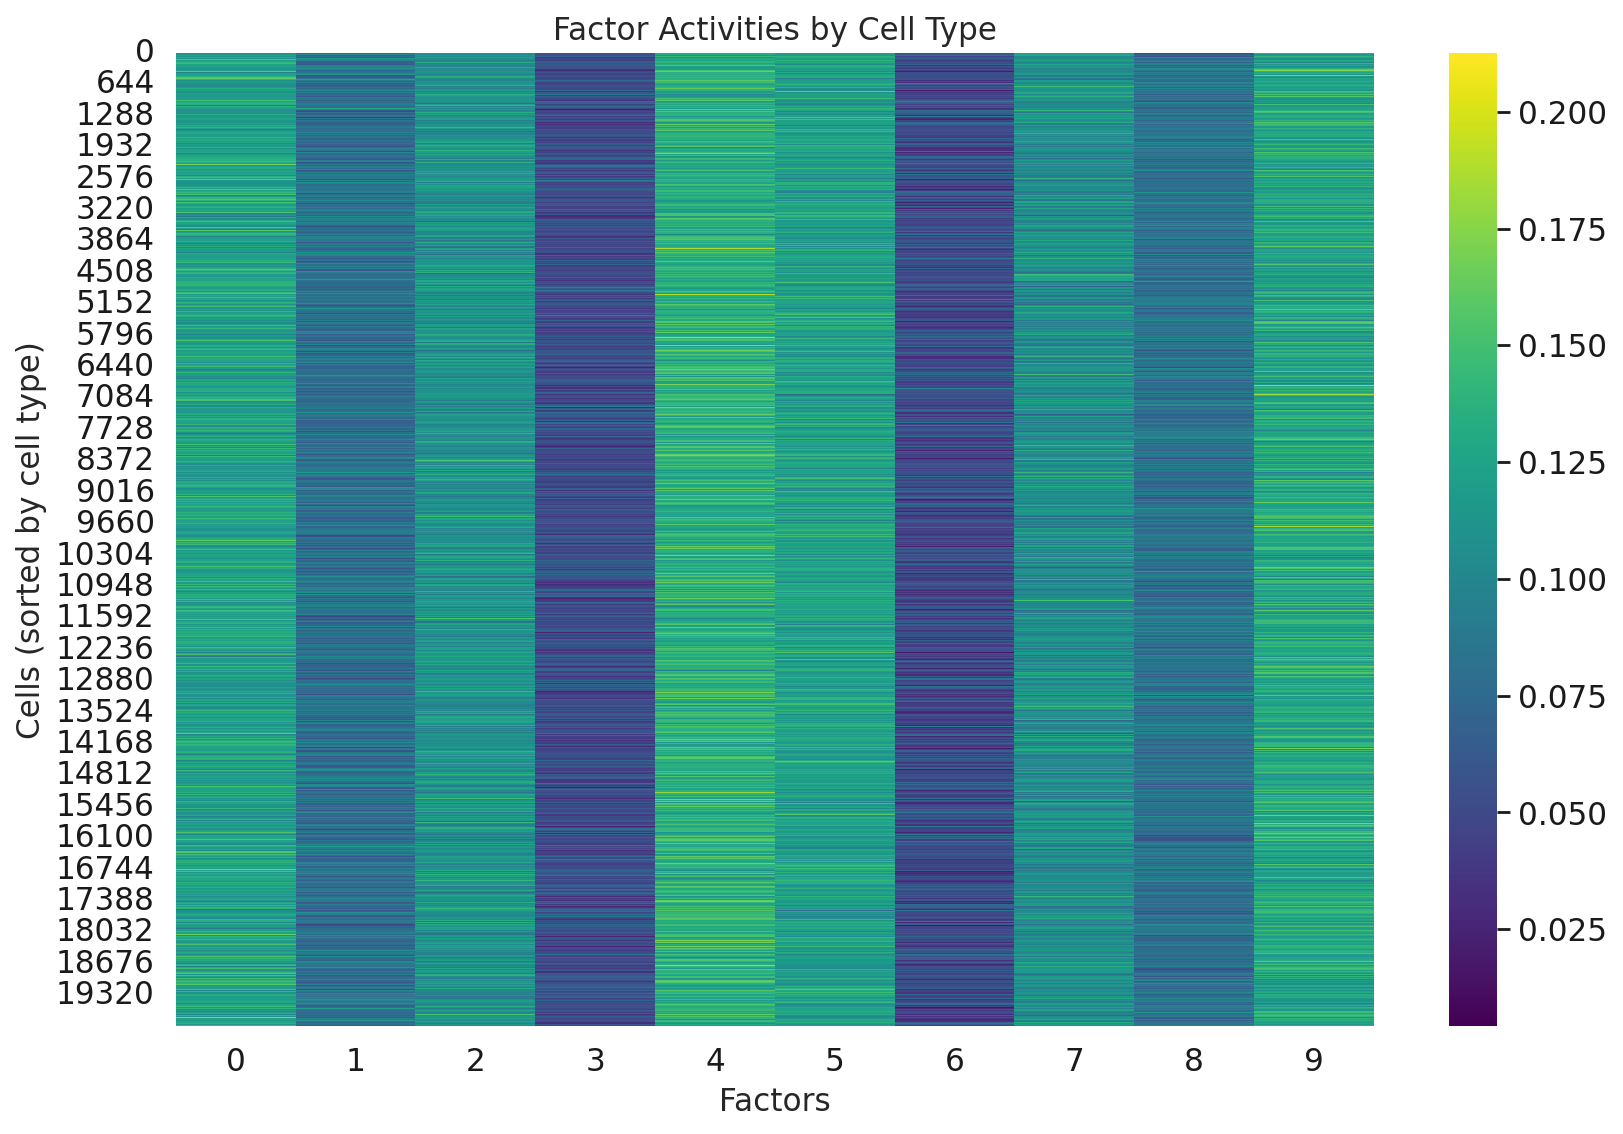

In [ ]:
# Calculate mean assignment (factor activities)
phi_mean = all_samples['assign'].mean(dim=0).detach().cpu().numpy()

# Plot a heatmap of factor activities across cells
import matplotlib.pyplot as plt
import seaborn as sns

# Sort cells by cell type
cell_types = adata_input.obs['cell_type'].values
unique_types = np.unique(cell_types)
sorted_indices = []

for ct in unique_types:
    indices = np.where(cell_types == ct)[0]
    sorted_indices.extend(indices)

# Create sorted heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(phi_mean[sorted_indices, :], cmap='viridis')
plt.title('Factor Activities by Cell Type')
plt.xlabel('Factors')
plt.ylabel('Cells (sorted by cell type)')
plt.show()

In [25]:
A = torch.randn(5, 4)
B = torch.randn(4, 6)
M = torch.randint(0, 2, (5, 6), dtype=torch.bool)
rows, cols = M.nonzero(as_tuple=True)
def masked_matmul(i, j):
    return (A[i] @ B[:, j])
values = torch.vmap(masked_matmul)(rows, cols)
result = torch.zeros_like(M, dtype=A.dtype)
result[M] = values
print(result)

RuntimeError: vmap: It looks like you're calling .item() on a Tensor. We don't support vmap over calling .item() on a Tensor, please try to rewrite what you're doing with other operations. If error is occurring somewhere inside PyTorch internals, please file a bug report.

In [ ]:
# get per cell sum of phi_mean
phi_sum = phi_mean.sum(axis=1)
phi_sum.min(), phi_sum.max()

(0.9999998, 1.0000001)

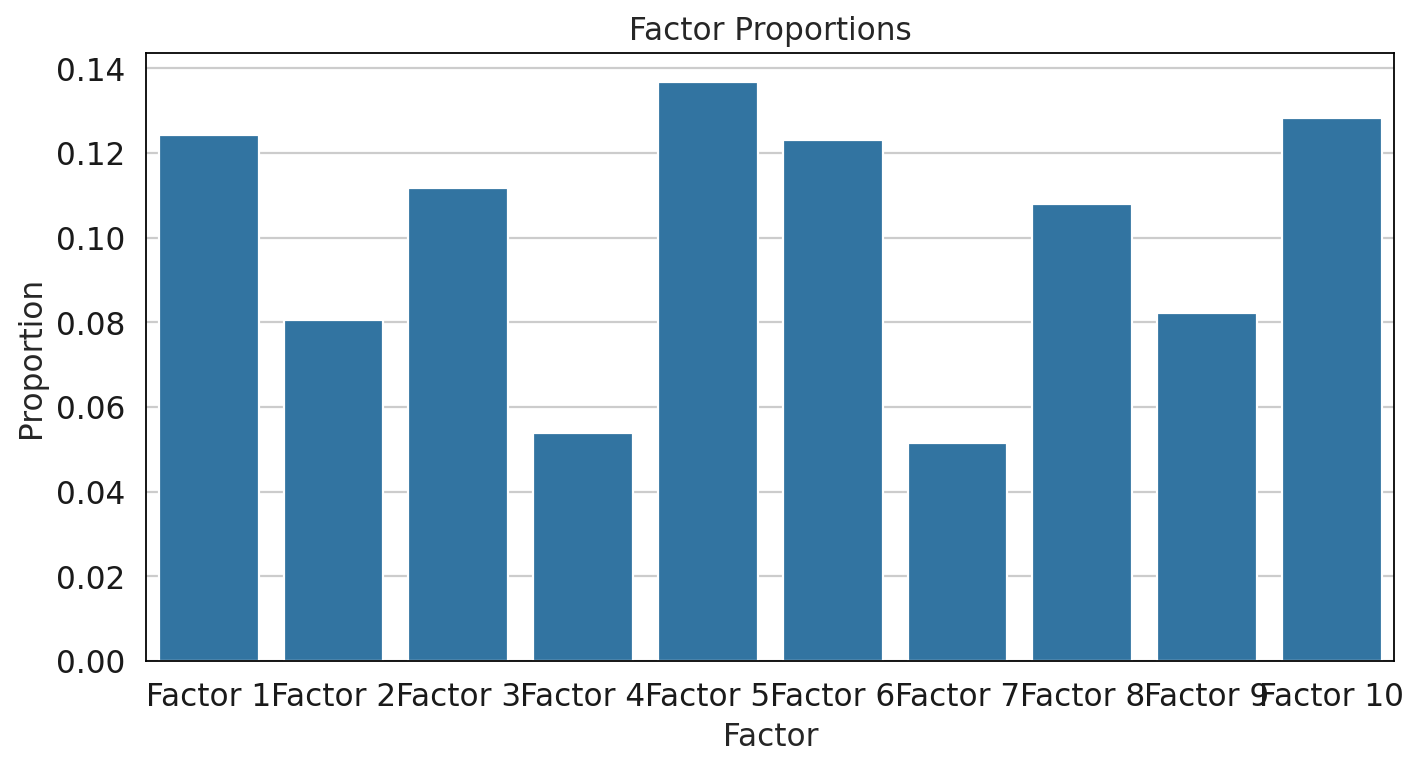

In [ ]:
# Extract PI and make a quick barplot
pi_mean = all_samples['pi'].mean(dim=0)
pi_mean = pi_mean.detach().cpu().numpy()
pi_df = pd.DataFrame(pi_mean, columns=[f"Factor {i+1}" for i in range(pi_mean.shape[1])])
pi_df = pi_df.melt(var_name="Factor", value_name="Proportion")

plt.figure(figsize=(10, 5))
sns.barplot(data=pi_df, x="Factor", y="Proportion")
plt.title("Factor Proportions")
plt.show()
